# Detecting heat pumps in aggregate load: slopes, thresholds and resolution

One dataset, built by merging **HEAPO** and the **Swiss** smart-meter dataset. The
merge is legitimate because HEAPO's weather station `8jB` is bit-for-bit identical
to MeteoSwiss **KLO**, the station the Swiss dataset uses (max |diff| = 0.0000 °C
across all 8760 hourly values of 2023), so the two cohorts share a station and
their households can sit in the same synthetic substation.

Restrictions carried over from each source:

* ≥90 % coverage of the required series over calendar 2023 at 15 min
* Swiss side: **dwellings only** (`Apartment`, `Single-family house`) — no common
  areas, underground garages, elevators or feed-in systems
* submetered heat-pump load is the only source of `HP_Peak` ground truth

**1702 consumers, 81 with a submetered heat pump.**

## What this notebook answers

1. Distributions of **slope** and **threshold temperature** from a hockey-stick fit
   of daily mean load on daily mean temperature.
2. **At what slope can a heat pump be confidently detected**, given that
   substations with *no* heat pumps also have non-zero slopes.
3. The same fit applied to the **simultaneity factor**, plus the projected
   **critical temperature** at which SF would reach 1.
4. How fit quality changes with **temporal resolution** (1 h, 4 h, 8 h, 16 h, 24 h),
   with **spatial aggregation**, and with both together.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import hp_pools as hpp
import hp_design as hd
import hp_analysis as ha
from hp_common import hockey_stick, T_BALANCE_BOUNDS

# All False -> load from cache (instant).
REBUILD_POOL = False         # re-read raw data: HEAPO ~7 min, Swiss ~10 min
REGENERATE_DESIGN = False    # re-draw the substation design
REFIT = False                # re-fit every substation at every resolution


## Substation design

Two designs are built, because no single grid serves both purposes.

The wide design spans 10 to 200 consumers on a penetration grid. Consumer count
is what gives the confound its leverage, so this range is what the detection
analysis rests on. Its consequence is that the realised matrix of consumer count
against heat pump count is sparse, because a given penetration produces different
heat pump counts at different sizes.

The triangular design indexes cells by absolute heat pump count and generates
only those with N_hp not greater than N_total, so every cell in the lower triangle
is filled. That makes the structure of the sensitivity surface legible, which is
what the central figure needs. A full triangle requires the heat pump count to reach
the consumer count, and the submetered heat pump pool caps this at 50 on the largest
weather station, so the triangle itself stops at 50 consumers.

It is then extended to the right, at 100, 150 and 200 consumers, on the same heat
pump ladder. Those columns are rectangular rather than triangular, since 50 heat
pumps is the ceiling however many consumers are added around them. That is the
point of them: within a row of constant N_hp, the only thing changing across the
extension is the number of consumers, so the row measures the confound directly.

Both draw households without replacement, keep every member of a substation on
one weather station, and include cells with no heat pumps as the detection
reference.

### Composition rule

The separation that matters is electric against non-electric heating, not heat
pumps against everything else. A substation with no heat pumps is only a useful
reference if it has no temperature-driven electric load at all, so every
non-heat-pump member is drawn from households with none of the five labelled
electric heating types: electric water heater, storage heating, direct heating,
auxiliary heat pump, water-heating heat pump. In practice those households heat
with gas, oil or district heat. Heat pump members are left alone and may carry
other electric heating on top of the heat pump.

The asymmetry is deliberate. Cleaning the non-heat-pump tier is free, because
1328 of the 1671 households on the largest weather station are clean. Cleaning
the heat pump tier is not: only 21 of the 50 submetered heat pumps are
themselves free of other electric heating, which would cut the ladder from 50 to
20 and remove most of the triangle. A strict variant run on the shorter ladder
shows the exclusion buys nothing, so the ladder is kept instead.

This removes *labelled* electric heating, which is not the same as all of it.
The Swiss metadata carries five flags, HEAPO only records electric water
heaters, and WPUQ has no appliance metadata at all. A clean control is clean to
the resolution of its own dataset's survey.

In [2]:
WIDE_DESIGN = 'data/design_wide.pkl'
TRI_DESIGN = 'data/design_tri.pkl'

# eheat_frac=0.0 with clean_hp=False is the composition rule used everywhere
# below: no non-heat-pump member has any electric heating, heat pump members
# may have some. See the markdown above for why the two tiers differ.
if REGENERATE_DESIGN or REBUILD_POOL:
    pool = hpp.build_pool_combined(rebuild=REBUILD_POOL)
    # wide: consumer range carries the detection argument
    design, cov_wide = hd.generate_design(
        pool, n_grid=[10, 20, 50, 100, 200],
        ratio_grid=[0.0, 0.05, 0.10, 0.25, 0.50, 0.75, 1.0],
        n_reps=40, eheat_frac=0.0, clean_hp=False, seed=42, verbose=False)
    hd.save_design(design, WIDE_DESIGN)
    # triangular: complete matrix for the structural figure, extended to the
    # right at 100/150/200 consumers on the same heat pump ladder. Those
    # columns are not triangular -- 50 submetered heat pumps is the ceiling --
    # but reading a row of constant N_hp into them isolates consumer count.
    design_tri, cov_tri = hd.generate_design(
        pool, n_grid=[5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 100, 150, 200],
        hp_grid=[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
        n_reps=25, eheat_frac=0.0, clean_hp=False, seed=42, verbose=False)
    hd.save_design(design_tri, TRI_DESIGN)
else:
    design = hd.load_design(WIDE_DESIGN)
    design_tri = hd.load_design(TRI_DESIGN)

meta, meta_tri = design['meta'], design_tri['meta']

# The heat pump pool, not the household pool, limits every SF result.
pool_stats = ha.pool_report(design, hpp.build_pool_combined(verbose=False))
print(f"households used     : {pool_stats['households_used']} "
      f"of {pool_stats['households_available']}")
print(f"HP households used  : {pool_stats['hp_households_used']} "
      f"of {pool_stats['hp_households_available']}")
print(f"HP peak (kW)        : median {pool_stats['hp_peak_median']:.2f}, "
      f"range {pool_stats['hp_peak_min']:.2f}-{pool_stats['hp_peak_max']:.2f}")
print()
print(f'wide design       : {len(meta)} substations, '
      f'N_total {sorted(meta.N_total.unique())}')
print(pd.crosstab(meta.N_total, meta.N_hp).to_string())
print()
print(f'triangular design : {len(meta_tri)} substations, '
      f'N_total {sorted(meta_tri.N_total.unique())}')
print(pd.crosstab(meta_tri.N_total, meta_tri.N_hp).to_string())


households used     : 1378 of 1702
HP households used  : 71 of 81
HP peak (kW)        : median 5.80, range 2.04-28.39

wide design       : 1200 substations, N_total [10, 20, 50, 100, 200]
N_hp     0   1   2   5   8   10  12  15  20  25  38  50
N_total                                                
10       80  40  40  40  40  40   0   0   0   0   0   0
20       40  40  40  40   0  40   0  40  40   0   0   0
50       40   0  40  40   0   0  40   0   0  40  40  40
100      40   0   0  40   0  40   0   0   0  40   0  40
200      40   0   0   0   0  40   0   0  40   0   0  40

triangular design : 2450 substations, N_total [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 100, 150, 200]
N_hp     0   5   10  15  20  25  30  35  40  45  50
N_total                                            
5        25  25   0   0   0   0   0   0   0   0   0
10       25  25  25   0   0   0   0   0   0   0   0
15       25  25  25  25   0   0   0   0   0   0   0
20       25  25  25  25  25   0   0   0   0   0   0
25    

## Fits

For every substation, at each of 1 h / 4 h / 8 h / 16 h / 24 h, a hockey stick
`y = base + slope · max(0, T_threshold − T)` is fitted for two responses:

* **Load** — mean net load against mean temperature (what a DSO observes)
* **SF** — simultaneity factor `HP_Load / HP_Peak` against mean temperature
  (submetered ground truth; undefined where there are no heat pumps)

`slope_per_peak` and `slope_per_base` normalise the slope by an **observable**
quantity. This matters for detection: the slope grows with ordinary consumers as
well as with heat pumps, and a DSO cannot divide by a household count it does not
have.

In [3]:
WIDE_FITS = 'data/wide_fits.parquet'
TRI_FITS = 'data/tri_fits.parquet'

if REFIT or REGENERATE_DESIGN:
    fits = ha.fit_all(design)
    fits.to_parquet(WIDE_FITS)
    tri_fits = ha.fit_all(design_tri)
    tri_fits.to_parquet(TRI_FITS)
else:
    fits = pd.read_parquet(WIDE_FITS)
    tri_fits = pd.read_parquet(TRI_FITS)

load_fits = fits[fits.response == 'Load']
sf_fits = fits[fits.response == 'SF']
# daily-resolution slices used throughout
d24 = load_fits[(load_fits.resolution == '24 h') & (~load_fits.failed)]
d24_tri = tri_fits[(tri_fits.response == 'Load') &
                   (tri_fits.resolution == '24 h') & (~tri_fits.failed)]
print(f'wide: {len(fits)} fits, triangular: {len(tri_fits)} fits, '
      f'{int(fits.failed.sum()) + int(tri_fits.failed.sum())} failed')


wide: 10800 fits, triangular: 22875 fits, 0 failed


## 1. Net-load hockey stick — slope and threshold temperature

Daily means (24 h). The slope distribution is shown separately for substations
with and without heat pumps, because their overlap is exactly what limits
detection.

  parameter    n  median     q25     q75      min    max
      slope 1200   1.074   0.380   2.648    0.000  7.546
T_threshold 1200  16.746  16.443  17.415    8.000 20.000
     T_crit  960 -33.615 -40.664 -20.405 -105.468  7.692


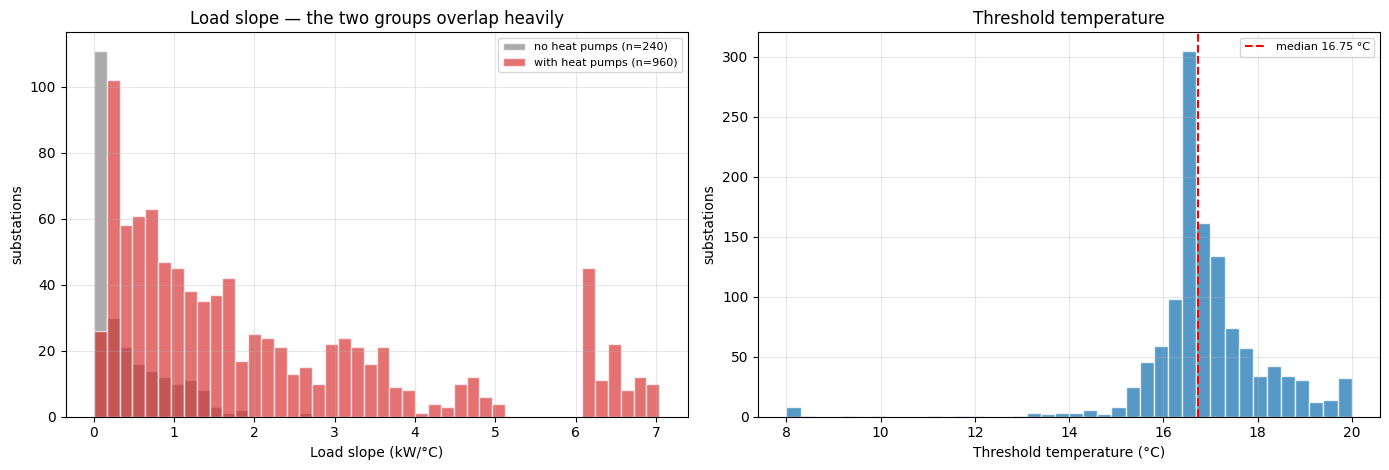

median slope: no HP 0.194 vs with HP 1.449 kW/°C
threshold temperature is stable at 16.75 °C (IQR 16.44-17.42)

response    n  pinned_low  pinned_high  pinned_frac  median_all  median_unpinned   shift
    Load 1200           8           26       0.0283     16.7456          16.7287 -0.0169
      SF  960           0            3       0.0031     16.4495          16.4495 -0.0000


In [4]:
print(ha.describe_params(fits, 'Load').round(3).to_string(index=False))

no_hp = d24[d24.N_hp == 0]
with_hp = d24[d24.N_hp > 0]

fig, axs = plt.subplots(1, 2, figsize=(14, 4.8))
bins = np.linspace(0, d24.slope.quantile(.99), 45)
axs[0].hist(no_hp.slope, bins=bins, alpha=.65, label=f'no heat pumps (n={len(no_hp)})',
            color='tab:grey', edgecolor='white')
axs[0].hist(with_hp.slope, bins=bins, alpha=.65, label=f'with heat pumps (n={len(with_hp)})',
            color='tab:red', edgecolor='white')
axs[0].set_xlabel('Load slope (kW/°C)'); axs[0].set_ylabel('substations')
axs[0].set_title('Load slope — the two groups overlap heavily')
axs[0].grid(alpha=.3); axs[0].legend(fontsize=8)

axs[1].hist(d24.T_threshold, bins=40, color='tab:blue', alpha=.75, edgecolor='white')
axs[1].axvline(d24.T_threshold.median(), color='red', ls='--',
               label=f'median {d24.T_threshold.median():.2f} °C')
axs[1].set_xlabel('Threshold temperature (°C)'); axs[1].set_ylabel('substations')
axs[1].set_title('Threshold temperature')
axs[1].grid(alpha=.3); axs[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

print(f'median slope: no HP {no_hp.slope.median():.3f} vs with HP '
      f'{with_hp.slope.median():.3f} kW/°C')
print(f'threshold temperature is stable at {d24.T_threshold.median():.2f} °C '
      f'(IQR {d24.T_threshold.quantile(.25):.2f}-{d24.T_threshold.quantile(.75):.2f})')

# A fit sitting on the search bound has not identified a breakpoint from the
# data. Report how many, and whether dropping them moves the median.
print()
print(ha.boundary_report(fits).round(4).to_string(index=False))


## 2. At what slope is a heat pump detectable?

A raw slope threshold cannot work, because the slope grows with **both** heat pumps
(~0.10–0.15 kW/°C each) and ordinary consumers (~0.006 kW/°C each). A large
substation with no heat pumps out-slopes a small one with several — visible in the
table below, where the no-heat-pump column reaches 1.20 kW/°C at 200 consumers,
more than a 10-consumer substation in which every household has a heat pump.

Detection therefore needs the slope normalised by something **observable without a
household census**: peak load or base load, never the consumer count. Each
candidate is scored by AUC, and the operating threshold is set at **95 %
specificity** — i.e. at most 5 % of heat-pump-free substations are flagged.

In [5]:
# The slope grows with consumers as well as with heat pumps, so a large
# HP-free substation out-slopes a small one that has heat pumps.
print('Median Load slope (kW/degC) at 24 h - rows = consumers, columns = heat pumps:')
print(d24.pivot_table(index='N_total', columns='N_hp', values='slope',
                      aggfunc='median').round(2).to_string())
print()

# Substations are the resampling unit. The operating threshold is the 95th
# percentile of the HP-free group, so it is itself an estimate.
N_BOOT = 1000
boot = ha.bootstrap_table(load_fits, n_boot=N_BOOT)
print(f'Detection statistics at 24 h, {N_BOOT} bootstrap replicates, '
      'specificity 0.95:')
print(boot.round(4).to_string(index=False))


Median Load slope (kW/degC) at 24 h - rows = consumers, columns = heat pumps:
N_hp       0     1     2     5     8     10    12    15    20    25   38    50
N_total                                                                       
10       0.14  0.19  0.29  0.59  0.86  1.03   NaN   NaN   NaN   NaN  NaN   NaN
20       0.08  0.23  0.30  0.66   NaN  1.32   NaN  1.89  2.33   NaN  NaN   NaN
50       0.31   NaN  0.46  0.77   NaN   NaN  1.61   NaN   NaN  3.19  4.7  6.11
100      0.63   NaN   NaN  1.17   NaN  1.68   NaN   NaN   NaN  3.29  NaN  6.43
200      1.20   NaN   NaN   NaN   NaN  2.40   NaN   NaN  3.37   NaN  NaN  6.89

Detection statistics at 24 h, 1000 bootstrap replicates, specificity 0.95:
     statistic    auc  auc_lo  auc_hi  threshold  thr_lo  thr_hi  sensitivity  sens_lo  sens_hi
         slope 0.8557  0.8297  0.8788     1.3481  1.2109  1.5527       0.5250   0.4791   0.5740
slope_per_peak 0.9545  0.9407  0.9669     0.0191  0.0173  0.0226       0.8260   0.6323   0.8865
slope

In [6]:
# The wide design cannot separate the two counts, because a penetration grid ties
# N_hp to N_total. The extended triangular design can: the columns beyond 50
# consumers carry the same absolute heat pump ladder, so along a row nothing
# changes except how many consumers surround a fixed number of heat pumps.
piv_tri = d24_tri.pivot_table(index='N_hp', columns='N_total', values='slope',
                              aggfunc='median')
n_max = int(piv_tri.columns.max())
hp_max = int(piv_tri.index.max())
print('Median Load slope (kW/degC) at 24 h, triangular design with the')
print('rectangular extension - rows = heat pumps, columns = consumers:')
print(piv_tri.round(2).to_string())
print()

print(f'Consumer effect at a FIXED heat pump count, 50 -> {n_max} consumers:')
for nhp in piv_tri.index:
    a, b = piv_tri.loc[nhp, 50], piv_tri.loc[nhp, n_max]
    print(f'  N_hp = {int(nhp):>3}:  {a:5.2f} -> {b:5.2f} kW/degC  (x{b / a:.2f})')
print()

print(f'Heat pump effect at a FIXED consumer count, 0 -> {hp_max} heat pumps:')
for ntot in [c for c in piv_tri.columns if c >= 50]:
    a, b = piv_tri.loc[0, ntot], piv_tri.loc[hp_max, ntot]
    print(f'  N_total = {int(ntot):>3}:  {a:5.2f} -> {b:5.2f} kW/degC  (x{b / a:.2f})')
print()

# Both counts raise the slope roughly additively, so one coefficient each
# summarises the surface. The ratio is what the confound costs.
grid = piv_tri.stack().rename('slope').reset_index()
X = np.column_stack([np.ones(len(grid)), grid.N_total, grid.N_hp])
c0, c_tot, c_hp = np.linalg.lstsq(X, grid.slope.values, rcond=None)[0]
print(f'least squares over the whole surface: slope = {c0:.2f} '
      f'+ {c_tot:.4f} per consumer + {c_hp:.4f} per heat pump')
print(f'one heat pump is worth about {c_hp / c_tot:.0f} ordinary consumers, so '
      f'{n_max} consumers')
print(f'without a single heat pump carry as much thermal sensitivity as roughly '
      f'{n_max * c_tot / c_hp:.0f} heat pumps.')
print()

free_big = piv_tri.loc[0, n_max]
col50 = piv_tri[50].dropna()
beaten = col50[col50 < free_big]
print(f'{n_max} consumers with no heat pump at all: {free_big:.2f} kW/degC.')
if len(beaten) > 1:
    k = int(beaten.index.max())
    print(f'That is steeper than a 50-consumer substation containing up to {k} heat')
    print(f'pumps ({k / 50:.0%} penetration, {col50[k]:.2f} kW/degC). Raw sensitivity')
    print('therefore cannot be read as evidence of heat pumps unless the consumer')
    print('count is already known, which is exactly what a substation meter does not')
    print('report.')
else:
    print('No heat pump count at 50 consumers is out-sloped by it, so over this')
    print('consumer range the confound does not invert the ranking.')


Median Load slope (kW/degC) at 24 h, triangular design with the
rectangular extension - rows = heat pumps, columns = consumers:
N_total   5     10    15    20    25    30    35    40    45    50    100   150   200
N_hp                                                                                 
0        0.05  0.14  0.06  0.09  0.11  0.18  0.15  0.19  0.25  0.28  0.72  0.87  1.28
5        0.52  0.59  0.65  0.62  0.73  0.73  0.65  0.73  0.86  0.83  1.09  1.58  1.74
10        NaN  1.04  1.31  1.25  1.25  1.28  1.31  1.41  1.36  1.40  1.82  2.10  2.52
15        NaN   NaN  1.72  1.97  1.81  1.91  1.91  1.95  1.96  2.04  2.24  2.68  2.93
20        NaN   NaN   NaN  2.64  2.46  2.46  2.51  2.53  2.48  2.51  3.03  3.19  3.57
25        NaN   NaN   NaN   NaN  3.11  3.23  3.17  3.11  3.13  3.24  3.52  3.91  4.08
30        NaN   NaN   NaN   NaN   NaN  3.63  3.71  3.71  3.82  3.98  3.99  4.22  4.63
35        NaN   NaN   NaN   NaN   NaN   NaN  4.33  4.29  4.41  4.29  4.56  5.06  5.17
40        Na

In [7]:
# Does the residual electric heating inside the HEAT PUMP tier matter? The
# strict variant excludes it as well, which caps the ladder at 20 heat pumps.
# If the two agree where they overlap, keeping the long ladder costs nothing.
strict = pd.read_parquet('data/tri_strict_fits.parquet')
s24 = strict[(strict.response == 'Load') & (strict.resolution == '24 h') &
             (~strict.failed)]
piv_strict = s24.pivot_table(index='N_hp', columns='N_total', values='slope',
                             aggfunc='median')
shared_n = [c for c in piv_strict.columns if c in piv_tri.columns]
shared_hp = [r for r in piv_strict.index if r in piv_tri.index]
delta = (piv_strict.loc[shared_hp, shared_n] - piv_tri.loc[shared_hp, shared_n])
print('strict minus adopted rule, kW/degC (heat pump tier cleaned as well):')
print(delta.round(2).to_string())
print()
print(f'largest disagreement {delta.abs().max().max():.2f} kW/degC, '
      f'median {delta.stack().median():+.2f}')
print('The heat pump tier can keep its electric heating: excluding it moves')
print('nothing, and it would cost more than half the heat pump ladder.')


strict minus adopted rule, kW/degC (heat pump tier cleaned as well):
N_total   5     10    15    20    50    100   150   200
N_hp                                                   
0        0.00  0.00  0.03 -0.01  0.03 -0.16  0.07 -0.04
5        0.09  0.09 -0.04  0.02 -0.00  0.03 -0.05  0.09
10        NaN  0.15 -0.03 -0.03 -0.00 -0.10  0.06 -0.15
15        NaN   NaN  0.12 -0.07 -0.02  0.07 -0.14 -0.09
20        NaN   NaN   NaN -0.21  0.01 -0.19 -0.01  0.01

largest disagreement 0.21 kW/degC, median -0.00
The heat pump tier can keep its electric heating: excluding it moves
nothing, and it would cost more than half the heat pump ladder.


raw slope: detect when statistic > 1.3481 kW/°C  -> sensitivity 0.525 at FPR 0.050
   by penetration: 5%=0.32  10%=0.39  25%=0.57  50%=0.61  75%=0.67  100%=0.69

slope / peak load: detect when statistic > 0.0191 1/°C  -> sensitivity 0.826 at FPR 0.050
   by penetration: 5%=0.39  10%=0.70  25%=0.95  50%=1.00  75%=1.00  100%=1.00



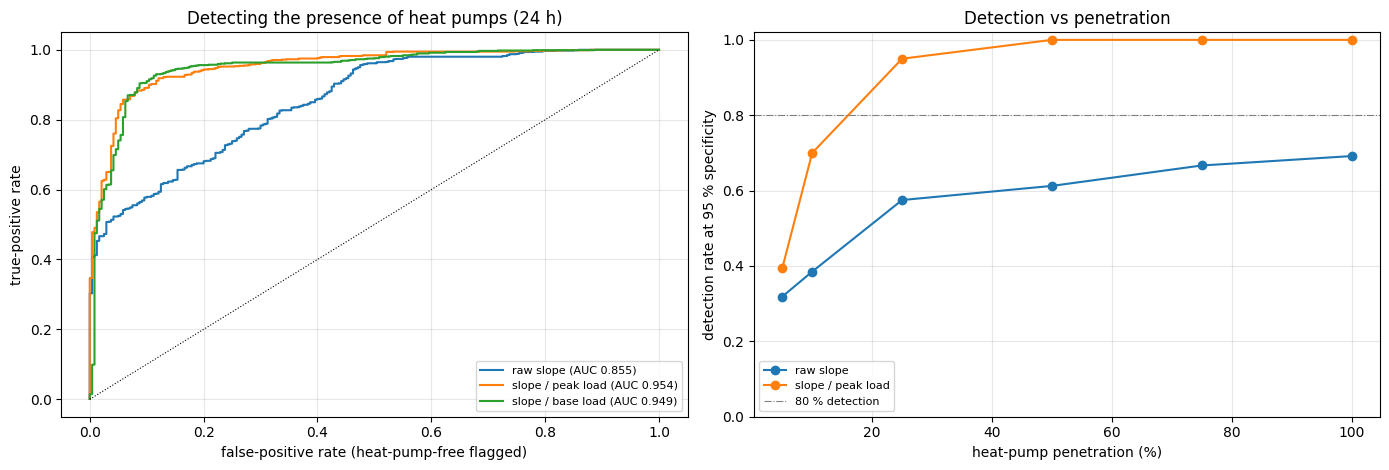

In [8]:
det_raw = ha.detection_threshold(load_fits, 'slope')
det_norm = ha.detection_threshold(load_fits, 'slope_per_peak')

for name, det, unit in [('raw slope', det_raw, ' kW/°C'),
                        ('slope / peak load', det_norm, ' 1/°C')]:
    print(f'{name}: detect when statistic > {det["threshold"]:.4f}{unit}'
          f'  -> sensitivity {det["sensitivity"]:.3f} at FPR {det["observed_fpr"]:.3f}')
    print('   by penetration: ' +
          '  '.join(f'{k:.0%}={v:.2f}' for k, v in det['by_hp_ratio'].items()))
    print()

fig, axs = plt.subplots(1, 2, figsize=(14, 4.8))
for stat, lab in [('slope', 'raw slope'), ('slope_per_peak', 'slope / peak load'),
                  ('slope_per_base', 'slope / base load')]:
    curve, auc = ha.roc(load_fits, stat)
    axs[0].plot(curve.fpr, curve.tpr, label=f'{lab} (AUC {auc:.3f})')
axs[0].plot([0, 1], [0, 1], 'k:', lw=.8)
axs[0].set_xlabel('false-positive rate (heat-pump-free flagged)')
axs[0].set_ylabel('true-positive rate')
axs[0].set_title('Detecting the presence of heat pumps (24 h)')
axs[0].grid(alpha=.3); axs[0].legend(fontsize=8)

for det, lab in [(det_raw, 'raw slope'), (det_norm, 'slope / peak load')]:
    s = det['by_hp_ratio']
    axs[1].plot(s.index * 100, s.values, 'o-', label=lab)
axs[1].axhline(.8, color='grey', ls='-.', lw=.8, label='80 % detection')
axs[1].set_xlabel('heat-pump penetration (%)')
axs[1].set_ylabel('detection rate at 95 % specificity')
axs[1].set_title('Detection vs penetration')
axs[1].set_ylim(0, 1.02); axs[1].grid(alpha=.3); axs[1].legend(fontsize=8)
fig.tight_layout(); plt.show()


In [9]:
# Sensitivity inherits the threshold's uncertainty, which is why its interval
# is so much wider than the AUC interval.
b = boot.set_index('statistic').loc['slope_per_peak']
print(f"slope / peak load at 24 h")
print(f"  AUC         {b.auc:.3f}  [{b.auc_lo:.3f}, {b.auc_hi:.3f}]")
print(f"  threshold   {b.threshold:.4f}  [{b.thr_lo:.4f}, {b.thr_hi:.4f}] 1/degC")
print(f"  sensitivity {b.sensitivity:.3f}  [{b.sens_lo:.3f}, {b.sens_hi:.3f}]")
print()
thr_lo_pc = 100 * (b.thr_lo / b.threshold - 1)
thr_hi_pc = 100 * (b.thr_hi / b.threshold - 1)
print(f'The threshold is estimated to {thr_lo_pc:+.0f}/{thr_hi_pc:+.0f} per cent, '
      f'but sensitivity spans')
print(f'{b.sens_lo:.2f} to {b.sens_hi:.2f}. An operator setting this threshold '
      f'from a sample of this')
print('size cannot predict its own detection rate precisely. That uncertainty is a')
print('property of the problem, not of the method.')


slope / peak load at 24 h
  AUC         0.954  [0.941, 0.967]
  threshold   0.0191  [0.0173, 0.0226] 1/degC
  sensitivity 0.826  [0.632, 0.886]

The threshold is estimated to -9/+18 per cent, but sensitivity spans
0.63 to 0.89. An operator setting this threshold from a sample of this
size cannot predict its own detection rate precisely. That uncertainty is a
property of the problem, not of the method.


In [10]:
# Whether detectability really peaks at an intermediate resolution needs a test,
# not just five separate point estimates. The same substations appear at every
# resolution, so each replicate resamples substations once and evaluates all
# resolutions on that draw, giving a paired difference.
res_contrast, ref_res = ha.bootstrap_resolution_contrast(
    load_fits, 'slope_per_peak', reference='24 h', n_boot=N_BOOT)
print(f'Paired contrast against {ref_res}:')
print(res_contrast.round(4).to_string(index=False))
print()
sig_auc = res_contrast[(res_contrast.d_auc_lo > 0) | (res_contrast.d_auc_hi < 0)]
sig_sen = res_contrast[(res_contrast.d_sens_lo > 0) | (res_contrast.d_sens_hi < 0)]
print('AUC differs from 24 h at:        ' + ', '.join(sig_auc.resolution))
print('sensitivity differs from 24 h at: ' + ', '.join(sig_sen.resolution))
print()
print('Detectability is highest at 1 to 4 h and falls towards daily, while fit')
print('quality keeps improving. Averaging tightens both groups, so the HP-free')
print('slopes rise too and the discriminating gap narrows. Fit quality and')
print('detectability are not the same objective.')


Paired contrast against 24 h:
resolution    auc  sensitivity  d_auc_vs_ref  d_auc_lo  d_auc_hi  d_sens_vs_ref  d_sens_lo  d_sens_hi
       1 h 0.9610       0.8594        0.0063    0.0016    0.0114         0.0437    -0.0177     0.1657
       4 h 0.9616       0.8438        0.0070    0.0030    0.0112         0.0352    -0.0240     0.1188
       8 h 0.9622       0.8458        0.0076    0.0040    0.0112         0.0361    -0.0219     0.1198
      16 h 0.9590       0.8333        0.0045    0.0015    0.0074         0.0183    -0.0229     0.0813
      24 h 0.9545       0.8260        0.0000    0.0000    0.0000         0.0000     0.0000     0.0000

AUC differs from 24 h at:        1 h, 4 h, 8 h, 16 h
sensitivity differs from 24 h at: 

Detectability is highest at 1 to 4 h and falls towards daily, while fit
quality keeps improving. Averaging tightens both groups, so the HP-free
slopes rise too and the discriminating gap narrows. Fit quality and
detectability are not the same objective.


The hockey stick estimates its own breakpoint. Heating degree hours instead fix
a base temperature and integrate the shortfall below it, so the hinge sits in the
regressor and the model becomes a plain line. The two parameterisations make
different assumptions, so running the identical detection analysis on both
separates what is a property of the estimator from what is a property of the
problem.

The base temperature is the one already defined in hp_common and used elsewhere
in the pipeline. No second constant is introduced. Note that it sits below the
balance temperature the hockey stick estimates from the data, so the two slopes
are not directly comparable in magnitude, only in what they can discriminate.

In [11]:
from hp_common import HDH_THRESH

HDH_FITS_PATH = 'data/wide_hdh_fits.parquet'
REFIT_HDH = False

if REFIT_HDH or REFIT or REGENERATE_DESIGN:
    hdh_fits = ha.fit_hdh_all(design)
    hdh_fits.to_parquet(HDH_FITS_PATH)
else:
    hdh_fits = pd.read_parquet(HDH_FITS_PATH)

hok = hdh_fits[~hdh_fits.failed]
print(f'HDH base temperature: {HDH_THRESH:.1f} degC (from hp_common)')
print(f'{len(hdh_fits)} fits, {int(hdh_fits.failed.sum())} failed, '
      f'median R2 {hok.r2.median():.3f}')
print(f'slope kW per degC.h : no heat pumps {hok[hok.N_hp == 0].slope.median():.4f}, '
      f'with heat pumps {hok[hok.N_hp > 0].slope.median():.4f}')


HDH base temperature: 12.0 degC (from hp_common)
1200 fits, 0 failed, median R2 0.806
slope kW per degC.h : no heat pumps 0.0108, with heat pumps 0.0821


In [12]:
# The same detection analysis, run on both parameterisations.
param_cmp = ha.parameterisation_comparison(load_fits, hdh_fits, n_boot=N_BOOT)
print(param_cmp.round(4).to_string(index=False))
print()

print('Detection rate against penetration, slope normalised by peak load:')
for nm, df in [('hockey stick', load_fits), ('HDH linear', hdh_fits)]:
    det = ha.detection_threshold(df, 'slope_per_peak', '24 h')
    print(f'  {nm:13s} ' + '  '.join(f'{k:.0%}={v:.2f}'
                                     for k, v in det['by_hp_ratio'].items()))
print()

# The confound is that the raw slope grows with consumers even when no heat
# pump is present. Check whether that survives the change of parameterisation.
print('Median raw slope of HP-free substations, by substation size:')
for nm, df in [('hockey stick', load_fits[load_fits.resolution == '24 h']),
               ('HDH linear', hdh_fits)]:
    z = df[(~df.failed) & (df.N_hp == 0)].groupby('N_total').slope.median()
    print(f'  {nm:13s} ' + '  '.join(f'N={int(k)}: {v:.3f}' for k, v in z.items()))
print()
_hs = load_fits[(load_fits.resolution == '24 h') & (~load_fits.failed) &
                (load_fits.N_hp == 0)].groupby('N_total').slope.median()
_hd = hdh_fits[(~hdh_fits.failed) & (hdh_fits.N_hp == 0)
               ].groupby('N_total').slope.median()
_auc = param_cmp.set_index(['parameterisation', 'statistic']).auc
_det = {nm: ha.detection_threshold(df, 'slope_per_peak', '24 h')['by_hp_ratio']
        for nm, df in [('hockey stick', load_fits), ('HDH linear', hdh_fits)]}
print('Both parameterisations behave the same way. The raw slope of a substation')
print(f'with no heat pumps rises by a factor of '
      f'{_hs.iloc[-1] / _hs.iloc[0]:.0f} (hockey stick) and '
      f'{_hd.iloc[-1] / _hd.iloc[0]:.0f} (HDH)')
print('from the smallest to the largest substation, so size and heat-pump count')
print('remain confounded. Normalising by peak load recovers the same')
print(f"discrimination in both cases, AUC {_auc[('hockey stick', 'slope_per_peak')]:.3f} "
      f"against {_auc[('HDH linear', 'slope_per_peak')]:.3f}, and leaves the")
print(f"same penetration behaviour: detection reaches "
      f"{_det['hockey stick'].loc[0.25]:.2f} at a quarter of households")
print(f"and {_det['hockey stick'].loc[0.05]:.2f} at five per cent. The confound is a "
      f'property of the problem, not')
print('of the hockey-stick parameterisation.')


parameterisation      statistic    auc  auc_lo  auc_hi  threshold  sensitivity  sens_lo  sens_hi
    hockey stick          slope 0.8557  0.8297  0.8788     1.3481       0.5250   0.4791   0.5740
    hockey stick slope_per_peak 0.9545  0.9407  0.9669     0.0191       0.8260   0.6323   0.8865
    hockey stick slope_per_base 0.9490  0.9326  0.9649     0.0452       0.7396   0.6010   0.8979
      HDH linear          slope 0.8526  0.8262  0.8764     0.0780       0.5198   0.4666   0.5636
      HDH linear slope_per_peak 0.9516  0.9368  0.9649     0.0011       0.7760   0.6646   0.8719
      HDH linear slope_per_base 0.9497  0.9333  0.9652     0.0023       0.7490   0.6146   0.8979

Detection rate against penetration, slope normalised by peak load:
  hockey stick  5%=0.39  10%=0.70  25%=0.95  50%=1.00  75%=1.00  100%=1.00
  HDH linear    5%=0.26  10%=0.61  25%=0.91  50%=1.00  75%=1.00  100%=1.00

Median raw slope of HP-free substations, by substation size:
  hockey stick  N=10: 0.139  N=20: 0.084 

## 3. Simultaneity factor

SF is the aggregated heat pump load divided by the sum of the individual
installed peaks, so it is bounded between zero and one. It is defined only where
heat pumps are present.

The temperature at which the fitted line would reach SF equal to one is computed
below, but it is not a design quantity and is not reported as one. It is included
because it shows how far the linear extrapolation has to be pushed to reach full
coincidence, and therefore that extrapolating the fit to that point is not
supported by the data. The quantity that can be used is SF at the coldest
conditions actually observed.

  from the SF fit:   T at SF = 1 is T_threshold minus (1 - base) / slope
  from the load fit: T at SF = 1 is T_threshold minus HP_Peak / slope

Comparing the two says how far the observable route departs from the submetered
one.

  parameter   n  median     q25     q75      min    max
      slope 960   0.016   0.015   0.018    0.006  0.040
T_threshold 960  16.450  16.090  16.756   12.032 20.000
     T_crit 960 -44.408 -48.276 -38.754 -135.254 -9.422


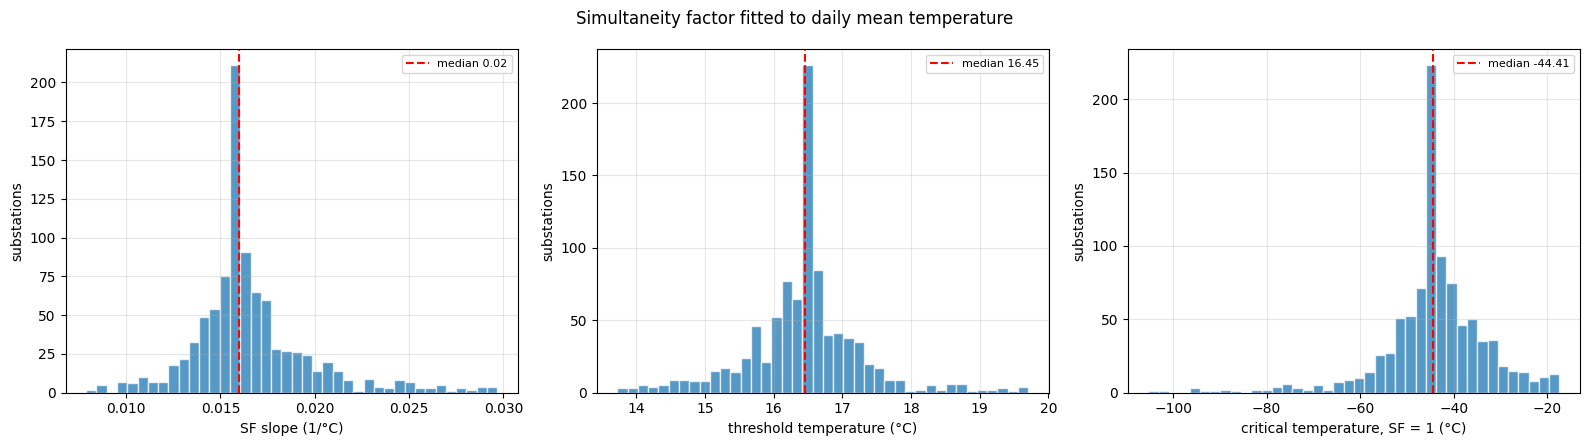

In [13]:
print(ha.describe_params(fits, 'SF').round(3).to_string(index=False))

s24 = sf_fits[(sf_fits.resolution == '24 h') & (~sf_fits.failed)]
specs = [('slope', 'SF slope (1/°C)'), ('T_threshold', 'threshold temperature (°C)'),
         ('T_crit', 'critical temperature, SF = 1 (°C)')]
fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (col, lab) in zip(axs, specs):
    v = s24[col].replace([np.inf, -np.inf], np.nan).dropna()
    lo, hi = v.quantile(.01), v.quantile(.99)
    ax.hist(v, bins=40, range=(lo, hi), color='tab:blue', alpha=.75, edgecolor='white')
    ax.axvline(v.median(), color='red', ls='--', label=f'median {v.median():.2f}')
    ax.set_xlabel(lab); ax.set_ylabel('substations'); ax.grid(alpha=.3)
    ax.legend(fontsize=8)
fig.suptitle('Simultaneity factor fitted to daily mean temperature')
fig.tight_layout(); plt.show()


In [14]:
# How far is SF = 1 from anything observed?
sf24 = s24.assign(SF_at_coldest=s24.base + s24.slope *
                  np.maximum(0.0, s24.T_threshold - s24.T_min_obs))
print(f'coldest observed daily mean : {s24.T_min_obs.median():.1f} °C')
print(f'modelled SF on that day     : {sf24.SF_at_coldest.median():.2f}'
      f'  [IQR {sf24.SF_at_coldest.quantile(.25):.2f}, '
      f'{sf24.SF_at_coldest.quantile(.75):.2f}]')
print(f'substations reaching SF = 1  : {int((sf24.SF_at_coldest >= 1).sum())} '
      f'of {len(sf24)}')
print()
ld = load_fits[(load_fits.resolution == '24 h') & (load_fits.N_hp > 0)]
cmp = pd.DataFrame({
    'SF_T_crit': s24.groupby('hp_ratio').T_crit.median(),
    'Load_T_crit': ld.groupby('hp_ratio').T_crit.median()})
cmp['gap'] = cmp.Load_T_crit - cmp.SF_T_crit
print('critical temperature: ground truth (SF) vs observable (net load)')
print(cmp.round(1).to_string())
print()
print('SF = 1 is never approached -- the projection sits far below any Swiss')
print('climate, so the empirically supported design point is SF ~ 0.4-0.5.')
print('The observable route is most optimistic where heat pumps are sparse and')
print('converges on ground truth only near full penetration.')


coldest observed daily mean : -8.2 °C
modelled SF on that day     : 0.42  [IQR 0.40, 0.46]
substations reaching SF = 1  : 0 of 960

critical temperature: ground truth (SF) vs observable (net load)
          SF_T_crit  Load_T_crit   gap
hp_ratio                              
0.05          -43.5        -12.0  31.5
0.10          -43.1        -22.1  21.0
0.25          -44.4        -33.5  10.9
0.50          -44.4        -37.6   6.8
0.75          -45.0        -41.4   3.6
1.00          -44.4        -41.3   3.1

SF = 1 is never approached -- the projection sits far below any Swiss
climate, so the empirically supported design point is SF ~ 0.4-0.5.
The observable route is most optimistic where heat pumps are sparse and
converges on ground truth only near full penetration.


The simultaneity factor also sets what the fleet can offer as flexibility. At a
given temperature the fraction of installed capacity currently drawing power is
SF(T), and that bounds how much can be turned down. The remainder, 1 - SF(T), is
idle and bounds how much can be turned up.

Both are fractions of installed capacity. Converting them to kW would need an
estimate of installed capacity, which the earlier sections show cannot be
recovered reliably from net load, so it is deliberately left out.

The curve is drawn across the observed temperature range and a short way beyond
it. The extrapolated part is shown separately because the SF fit is linear below
its threshold and there is no evidence that it stays linear outside the range
where it was estimated.

In [15]:
flex, t_range = ha.flexibility_envelope(sf_fits, design)
flex_stats = ha.flexibility_summary(sf_fits, flex, t_range)

print(f'observed daily mean temperature: {t_range[0]:.1f} to {t_range[1]:.1f} degC')
print(f'SF at the coldest observed day : {flex_stats.SF_at_coldest_observed:.3f} '
      f'[{flex_stats.SF_at_coldest_q25:.3f}, {flex_stats.SF_at_coldest_q75:.3f}]')
print(f'  downward flexibility there   : {flex_stats.down_at_coldest:.3f} of capacity')
print(f'  upward flexibility there     : {flex_stats.up_at_coldest:.3f} of capacity')
print(f'dSF/dT                         : {flex_stats.dSF_dT_median:.4f} per degC '
      f'[{flex_stats.dSF_dT_q25:.4f}, {flex_stats.dSF_dT_q75:.4f}]')
print(f'  i.e. {abs(flex_stats.dSF_per_5K):.3f} of capacity per 5 K of cooling')
print()
for T in [-9, -5, 0, 5, 10, 15, 20]:
    if T < t_range[0] or T > t_range[1]:
        continue
    r = flex.iloc[int((flex['T'] - T).abs().values.argmin())]
    print(f'  T = {T:>3} degC   down {r.down_median:.3f}   up {r.up_median:.3f}')


observed daily mean temperature: -9.6 to 27.7 degC
SF at the coldest observed day : 0.440 [0.415, 0.482]
  downward flexibility there   : 0.440 of capacity
  upward flexibility there     : 0.560 of capacity
dSF/dT                         : -0.0160 per degC [-0.0176, -0.0150]
  i.e. 0.080 of capacity per 5 K of cooling

  T =  -9 degC   down 0.433   up 0.567
  T =  -5 degC   down 0.371   up 0.629
  T =   0 degC   down 0.291   up 0.709
  T =   5 degC   down 0.211   up 0.789
  T =  10 degC   down 0.131   up 0.869
  T =  15 degC   down 0.051   up 0.949
  T =  20 degC   down 0.027   up 0.973


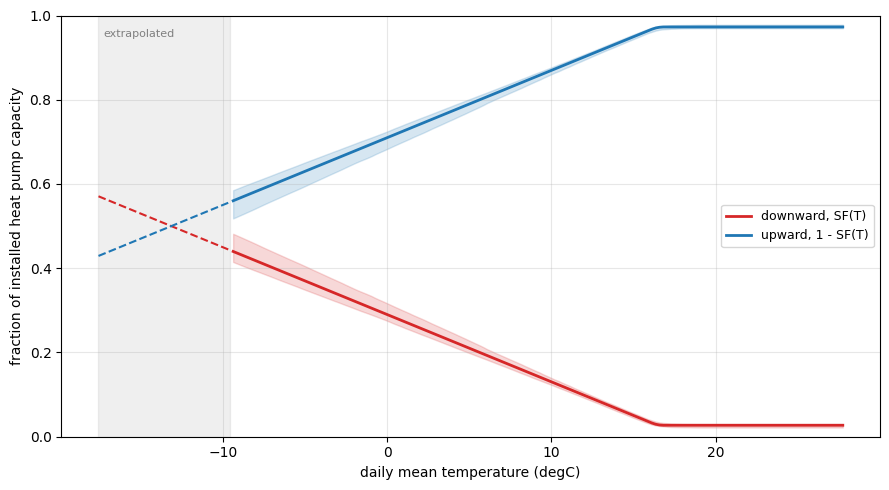

Downward flexibility grows as it gets colder but stays below half of
installed capacity everywhere in the observed range, peaking near 0.44.
Upward flexibility is the mirror image and never falls below about 0.56,
so most of the fleet is idle even on the coldest observed day. The two
resources are therefore asymmetric in the direction that matters for
winter peak management: the downward resource is smallest when the system
needs it, and it grows only about 0.08 of capacity per 5 K of cooling.


In [16]:
obs = flex[flex.observed]
ext = flex[~flex.observed]

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(obs['T'], obs.down_q25, obs.down_q75, color='tab:red', alpha=.18)
ax.plot(obs['T'], obs.down_median, color='tab:red', lw=2,
        label='downward, SF(T)')
ax.fill_between(obs['T'], obs.up_q25, obs.up_q75, color='tab:blue', alpha=.18)
ax.plot(obs['T'], obs.up_median, color='tab:blue', lw=2,
        label='upward, 1 - SF(T)')
# extrapolated region, dashed so it is not read as measured
ax.plot(ext['T'], ext.down_median, color='tab:red', lw=1.5, ls='--')
ax.plot(ext['T'], ext.up_median, color='tab:blue', lw=1.5, ls='--')
ax.axvspan(flex['T'].min(), t_range[0], color='grey', alpha=.12)
ax.text(flex['T'].min() + 0.3, 0.95, 'extrapolated', fontsize=8, color='grey')
ax.set_xlabel('daily mean temperature (degC)')
ax.set_ylabel('fraction of installed heat pump capacity')
ax.set_ylim(0, 1); ax.grid(alpha=.3); ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

print('Downward flexibility grows as it gets colder but stays below half of')
print('installed capacity everywhere in the observed range, peaking near 0.44.')
print('Upward flexibility is the mirror image and never falls below about 0.56,')
print('so most of the fleet is idle even on the coldest observed day. The two')
print('resources are therefore asymmetric in the direction that matters for')
print('winter peak management: the downward resource is smallest when the system')
print('needs it, and it grows only about 0.08 of capacity per 5 K of cooling.')


## 4. Fit quality vs resolution and aggregation

Three questions at once: does coarser averaging help, does a bigger substation
help, and do they act on the same thing? The mixed model separates the consumer
count from the heat-pump count, which a plain size variable cannot do.

In [17]:
for resp in ['Load', 'SF']:
    print(f'median R² — {resp}  (rows = consumers, columns = resolution)')
    print(ha.quality_grid(fits, resp).round(3).to_string())
    print()


median R² — Load  (rows = consumers, columns = resolution)
resolution    1 h    4 h    8 h   16 h   24 h
N_total                                      
10          0.332  0.457  0.577  0.706  0.784
20          0.519  0.646  0.731  0.839  0.898
50          0.568  0.667  0.753  0.867  0.918
100         0.420  0.491  0.573  0.786  0.885
200         0.370  0.437  0.523  0.771  0.891

median R² — SF  (rows = consumers, columns = resolution)
resolution    1 h    4 h    8 h   16 h   24 h
N_total                                      
10          0.681  0.838  0.907  0.941  0.956
20          0.767  0.892  0.927  0.953  0.965
50          0.841  0.921  0.943  0.963  0.972
100         0.836  0.923  0.946  0.965  0.972
200         0.847  0.926  0.951  0.968  0.975



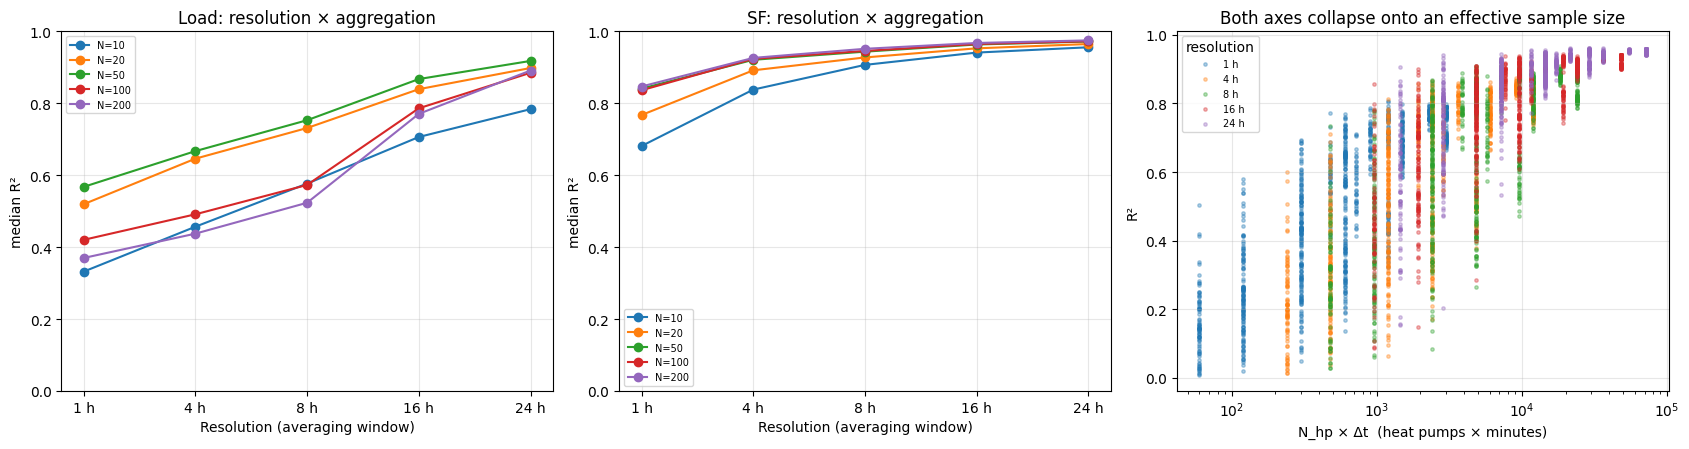

In [18]:
fig, axs = plt.subplots(1, 3, figsize=(17, 4.6))

for resp, ax in zip(['Load', 'SF'], axs[:2]):
    grid = ha.quality_grid(fits, resp)
    for n in grid.index:
        ax.plot(range(len(grid.columns)), grid.loc[n], 'o-', label=f'N={n}')
    ax.set_xticks(range(len(grid.columns)))
    ax.set_xticklabels(grid.columns)
    ax.set_xlabel('Resolution (averaging window)')
    ax.set_ylabel('median R²')
    ax.set_title(f'{resp}: resolution × aggregation')
    ax.set_ylim(0, 1); ax.grid(alpha=.3); ax.legend(fontsize=7)

# combined axis: effective sample size N_hp * dt
ok = fits[(~fits.failed) & (fits.response == 'Load') & (fits.N_hp > 0)].copy()
ok['neff'] = ok.N_hp * ok.dt_minutes
for r in ha.LABELS:
    s = ok[ok.resolution == r]
    axs[2].scatter(s.neff, s.r2, s=6, alpha=.35, label=r)
axs[2].set_xscale('log')
axs[2].set_xlabel('N_hp × Δt  (heat pumps × minutes)')
axs[2].set_ylabel('R²')
axs[2].set_title('Both axes collapse onto an effective sample size')
axs[2].grid(alpha=.3); axs[2].legend(fontsize=7, title='resolution')
fig.tight_layout(); plt.show()


In [19]:
print('logit(R²) ~ log Δt + log N_total + log N_hp   (substation random effect)')
for resp in ['Load', 'SF']:
    print(f'\n--- {resp} ---')
    print(ha.quality_model(fits, resp).round(3).to_string(index=False))
print()
print('log_dt  > 0 : coarser averaging always helps')
print('log_Nhp > 0 : more heat pumps help, and this term dominates')
print('log_N       : for net load slightly NEGATIVE -- extra non-HP consumers add')
print('              load uncorrelated with temperature and dilute the signal.')
print('              For SF it is ~0, as it must be: SF is already normalised by')
print('              installed capacity, so substation size cannot matter.')


logit(R²) ~ log Δt + log N_total + log N_hp   (substation random effect)

--- Load ---
   term   coef     lo     hi
 log_dt  0.662  0.654  0.671
  log_N -0.493 -0.526 -0.461
log_Nhp  0.959  0.931  0.987

--- SF ---
   term  coef     lo    hi
 log_dt 0.655  0.649 0.661
  log_N 0.025 -0.006 0.056
log_Nhp 0.434  0.408 0.461

log_dt  > 0 : coarser averaging always helps
log_Nhp > 0 : more heat pumps help, and this term dominates
log_N       : for net load slightly NEGATIVE -- extra non-HP consumers add
              load uncorrelated with temperature and dilute the signal.
              For SF it is ~0, as it must be: SF is already normalised by
              installed capacity, so substation size cannot matter.


Averaging reduces the residual and raises R2, but by how much depends on how
correlated the residuals are. If they were independent, averaging m samples
would divide the residual variance by m, so 1 - R2 would fall as 1/dt and
logit(R2) would rise by exactly one per e-fold of dt. That gives a benchmark of
alpha = 1 to compare against.

The pooled model fits a single coefficient on log(dt). The relationship is not
linear in that space, so the local slope between adjacent resolutions is the
more informative quantity, and it is computed within each substation so the
comparison stays paired.

In [20]:
# Local slope between adjacent resolutions, per aggregation level.
steps = [('1 h', '4 h'), ('4 h', '8 h'), ('8 h', '16 h'), ('16 h', '24 h')]
order = pd.MultiIndex.from_tuples(steps, names=['from', 'to'])

for resp in ['Load', 'SF']:
    loc = ha.local_scaling_slopes(fits, resp)
    piv = loc.pivot_table(index='N_total', columns=['from', 'to'],
                          values='alpha').reindex(columns=order)
    print(f'{resp}: local alpha = d logit(R2) / d log(dt)')
    print(piv.round(3).to_string())
    print()


Load: local alpha = d logit(R2) / d log(dt)
from       1 h    4 h    8 h   16 h
to         4 h    8 h   16 h   24 h
N_total                            
10       0.414  0.507  0.854  0.790
20       0.365  0.540  0.988  1.052
50       0.343  0.462  1.026  1.115
100      0.262  0.433  1.268  1.505
200      0.208  0.459  1.534  2.009

SF: local alpha = d logit(R2) / d log(dt)
from       1 h    4 h    8 h   16 h
to         4 h    8 h   16 h   24 h
N_total                            
10       0.634  0.801  0.709  0.709
20       0.594  0.683  0.668  0.702
50       0.541  0.510  0.607  0.643
100      0.551  0.494  0.607  0.643
200      0.524  0.423  0.607  0.643



In [21]:
# Pooled coefficients for comparison. They are nearly identical for the two
# responses, which is exactly what the local slopes show to be misleading.
for resp in ['Load', 'SF']:
    q = ha.quality_model(fits, resp).set_index('term')
    loc = ha.local_scaling_slopes(fits, resp)
    lo = loc.groupby(['from', 'to']).alpha.median().reindex(order)
    print(f'{resp:5s} pooled log_dt = {q.loc["log_dt", "coef"]:.3f}   '
          f'local alpha by step: ' +
          '  '.join(f'{a}->{b} {v:.2f}' for (a, b), v in lo.items()))
print()
_la = ha.local_scaling_slopes(fits, 'Load').groupby(['from', 'to']).alpha.median(
    ).reindex(order)
print(f'Net load: alpha climbs from about {_la.iloc[0]:.2f} at the finest step '
      f'to about {_la.iloc[-1]:.1f}')
print('at the coarsest, and exceeds 1 for the largest substations. Below 1 the')
print('residuals are correlated and averaging buys less than independence would.')
print('Above 1 averaging is removing structure, not just noise: the 8 h to 24 h')
print('steps span the diurnal cycle, which is systematic rather than random.')
print()
print('SF stays near 0.5 to 0.65 at every step and barely varies with aggregation.')
print('Both responses give a pooled coefficient near 0.66, so the single number')
print('conceals two quite different behaviours. That is the reason for reporting')
print('the local slopes as the primary result and keeping the pooled model only')
print('as a summary.')


Load  pooled log_dt = 0.662   local alpha by step: 1 h->4 h 0.34  4 h->8 h 0.46  8 h->16 h 1.03  16 h->24 h 1.11
SF    pooled log_dt = 0.655   local alpha by step: 1 h->4 h 0.55  4 h->8 h 0.51  8 h->16 h 0.61  16 h->24 h 0.64

Net load: alpha climbs from about 0.34 at the finest step to about 1.1
at the coarsest, and exceeds 1 for the largest substations. Below 1 the
residuals are correlated and averaging buys less than independence would.
Above 1 averaging is removing structure, not just noise: the 8 h to 24 h
steps span the diurnal cycle, which is systematic rather than random.

SF stays near 0.5 to 0.65 at every step and barely varies with aggregation.
Both responses give a pooled coefficient near 0.66, so the single number
conceals two quite different behaviours. That is the reason for reporting
the local slopes as the primary result and keeping the pooled model only
as a summary.


Drawing households uniformly from the pool produces the most diverse aggregate
possible. Real feeders are not like that: households on one feeder share building
age and construction type, and heat pumps tend to arrive in installation cohorts.
Less diversity means more coincident operation, which changes both the slope and
what can be detected.

What metadata is actually available limits how far this can be tested. The
combined pool has dwelling category for every household, which is the only
composition variable present for both cohorts. Heat pump vintage, model and
control strategy are not recorded in either dataset, so clustering by
installation cohort cannot be done at all and no proxy is substituted for it.

One further constraint decides the design. Of the 81 submetered heat pumps, 80
are in houses and one is in an apartment, so an apartment-clustered arm with heat
pumps in it does not exist. The clustered arm is therefore house-only
substations, compared against the random draw, which is about four fifths
apartments. That is a genuine reduction in diversity even though it is not the
cohort clustering the argument would ideally use.

In [22]:
CLUSTER_DESIGN = 'data/design_clustered.pkl'
CLUSTER_FITS = 'data/clustered_fits.parquet'
REGENERATE_CLUSTER = False

if REGENERATE_CLUSTER:
    pool_all = hpp.build_pool_combined(verbose=False)
    groups = hpp.dwelling_groups(pool_all)
    print(groups.value_counts().to_string())
    houses = [h for h in pool_all['households'] if groups[h] == 'house']
    pool_house = hpp.restrict_pool(pool_all, houses)
    design_cl, cov_cl = hd.generate_design(
        pool_house, n_grid=[5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
        hp_grid=[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
        n_reps=25, eheat_frac=0.0, clean_hp=False, seed=42, verbose=False)
    hd.save_design(design_cl, CLUSTER_DESIGN)
    cluster_fits = ha.fit_all(design_cl, verbose=False)
    cluster_fits.to_parquet(CLUSTER_FITS)
else:
    design_cl = hd.load_design(CLUSTER_DESIGN)
    cluster_fits = pd.read_parquet(CLUSTER_FITS)

print(f'clustered arm: {len(design_cl["meta"])} substations from '
      f'{design_cl["n_distinct_households_used"]} houses')


clustered arm: 1600 substations from 163 houses


In [23]:
# Same grid, same fits, only the composition of the draw differs.
rows = []
for nm, F, D in [('random', fits, design), ('clustered', cluster_fits, design_cl)]:
    sf = F[(F.response == 'SF') & (F.resolution == '24 h') & (~F.failed)]
    ld = F[(F.response == 'Load') & (F.resolution == '24 h') & (~F.failed)]
    env, rng = ha.flexibility_envelope(F[F.response == 'SF'], D)
    det = ha.detection_threshold(F[F.response == 'Load'], 'slope_per_peak', '24 h')
    _, auc = ha.roc(F[F.response == 'Load'], 'slope_per_peak', '24 h')
    b = det['by_hp_ratio']
    reached = b[b > 0.8]
    rows.append({'arm': nm, 'n_sf': len(sf),
                 'SF_at_coldest': env[env.observed].iloc[0].sf_median,
                 'SF_slope': sf.slope.median(),
                 'Load_slope': ld.slope.median(),
                 'auc': auc,
                 'detection_floor': (reached.index.min() if len(reached) else np.nan)})
print(pd.DataFrame(rows).round(4).to_string(index=False))
print()
print('detection rate by penetration:')
for nm, F in [('random', fits), ('clustered', cluster_fits)]:
    det = ha.detection_threshold(F[F.response == 'Load'], 'slope_per_peak', '24 h')
    print(f'  {nm:10s} ' + '  '.join(f'{k:.0%}={v:.2f}'
                                     for k, v in det['by_hp_ratio'].items()))


      arm  n_sf  SF_at_coldest  SF_slope  Load_slope    auc  detection_floor
   random   960         0.4398    0.0160      1.0745 0.9540           0.2500
clustered  1350         0.4456    0.0163      2.4709 0.9163           0.5556

detection rate by penetration:
  random     5%=0.39  10%=0.70  25%=0.95  50%=1.00  75%=1.00  100%=1.00
  clustered  10%=0.04  11%=0.20  12%=0.04  14%=0.16  17%=0.20  20%=0.16  22%=0.12  25%=0.40  29%=0.32  30%=0.36  33%=0.48  38%=0.48  40%=0.48  43%=0.48  44%=0.72  50%=0.66  56%=0.88  57%=0.68  60%=0.84  62%=0.92  67%=0.89  70%=1.00  71%=1.00  75%=0.96  78%=1.00  80%=0.92  83%=0.96  86%=1.00  88%=1.00  89%=1.00  90%=1.00  100%=0.97


The direction is the one the argument predicts for the slope and the opposite of
what might be expected for detection.

Simultaneity barely moves. SF at the coldest observed day is 0.440 under random
draw and 0.446 clustered, and the SF slope changes from 0.0160 to 0.0163 per
degree. Restricting to houses does not make the heat pumps operate together to
any meaningful extent, which is consistent with SF being set by thermostat cycling
and building thermal mass rather than by dwelling category.

The net load slope rises substantially, from 1.07 to 2.47 kW per degree. Houses
have larger and more temperature-sensitive baseline loads than apartments, so a
house-only substation has a steeper slope at the same heat pump count.

Detection gets worse, not better. AUC falls from 0.954 to 0.916 and the penetration
needed for 80 per cent detection moves from 25 to 56 per cent. The reason is the
second effect above. When the heat-pump-free houses already have steep slopes, the
gap that detection depends on closes. Clustering raises the reference group as much
as it raises the signal.

This penalty was far larger before the controls were cleaned of electric heating
(AUC 0.845 to 0.675 at the time), which is the same lesson in a different place:
much of what looked like a composition effect was an appliance effect.

This strengthens the paper's argument rather than weakening it. The penetration
floor found under random draw is the optimistic case, because random draw is the
composition most favourable to discrimination. A real feeder, being more
homogeneous, sits somewhere between these two arms and closer to the worse one.

WPUQ is 38 German single-family houses on one low-voltage feeder, each with
separately metered heat pump and household circuits, for calendar 2019. It gives
a second climate, a different building stock and an independent measurement
chain, so it tests whether the Swiss results are specific to their setting.

Two properties of the dataset need stating before the results.

The temperature series is recorded every five minutes, so it carries genuine
sub-hourly variation. The Swiss series is hourly and interpolated. This would
make the finest resolution contrast uninformative for the Swiss data, but the
coarsest step used anywhere here is one hour, so every resolution in the analysis
rests on genuine hourly temperature in both datasets and nothing needs excluding.

The data is from 2019. German provisions for controllable heat pump loads came
into force in 2024 and allow operator-side curtailment, which would make part of
any observed simultaneity a regulatory artefact rather than a physical one. Being
five years earlier, this data is unaffected.

The feeder also has a measured transformer, which allows something the Swiss data
cannot support: comparing synthetic aggregation against a real one.

In [24]:
WPUQ_DESIGN = 'data/design_wpuq_val.pkl'
WPUQ_FITS = 'data/wpuq_val_fits.parquet'
REGENERATE_WPUQ = False

if REGENERATE_WPUQ:
    wpuq_pool = hpp.build_pool_wpuq(rebuild=REBUILD_POOL)
    wpuq_design, _ = hd.generate_design(
        # the same penetration grid Switzerland uses, capped at the 35
        # available households, so both detection curves span the same range
        wpuq_pool, n_grid=[10, 20, 35],
        ratio_grid=[0.0, 0.05, 0.10, 0.25, 0.50, 0.75, 1.0],
        # the same rule, though it is a no-op here: WPUQ carries no appliance
        # metadata, so nothing is flagged and the draw is unchanged. Its
        # controls are clean by construction anyway, being metered houses
        # with the heat pump circuit omitted.
        n_reps=40, eheat_frac=0.0, clean_hp=False, seed=42, verbose=False)
    hd.save_design(wpuq_design, WPUQ_DESIGN)
    wpuq_fits = ha.fit_all(wpuq_design, verbose=False)
    wpuq_fits.to_parquet(WPUQ_FITS)
else:
    wpuq_pool = hpp.build_pool_wpuq(verbose=False)
    wpuq_design = hd.load_design(WPUQ_DESIGN)
    wpuq_fits = pd.read_parquet(WPUQ_FITS)

wpuq_load = wpuq_fits[wpuq_fits.response == 'Load']
wpuq_sf = wpuq_fits[wpuq_fits.response == 'SF']
print(f'{len(wpuq_design["meta"])} substations from '
      f'{wpuq_design["n_distinct_households_used"]} households, all with heat pumps')


840 substations from 37 households, all with heat pumps


In [25]:
# The measured transformer on the same feeder. Comparing it against the sum of
# the monitored households says how much of a real feeder the monitored set
# actually represents.
import h5py

widx = wpuq_pool['index']
wT = pd.Series(wpuq_pool['temperature']['WPUQ'], index=widx)
with h5py.File('data/2019_data_15min.hdf5', 'r') as _h:
    _t = _h['MISC']['ES1']['TRANSFORMER']['table'][:]
transformer = pd.Series(_t['P_TOT'] / 1000,
                        index=pd.to_datetime(_t['index'], unit='s', utc=True)).sort_index()
transformer = transformer[~transformer.index.duplicated()].reindex(widx).interpolate().clip(lower=0)

mon_hp = pd.Series(wpuq_pool['hp_mat'].sum(axis=0), index=widx)
mon_tot = mon_hp + pd.Series(wpuq_pool['other_mat'].sum(axis=0), index=widx)
hp_peak_total = float(wpuq_pool['hp_peak'].sum())

print(f'transformer            mean {transformer.mean():6.1f} kW  peak {transformer.max():6.1f} kW')
print(f'monitored households   mean {mon_tot.mean():6.1f} kW  peak {mon_tot.max():6.1f} kW')
print(f'monitored share of the real feeder: {100 * mon_tot.mean() / transformer.mean():.1f}%')
print(f'shape correlation: {np.corrcoef(transformer.values, mon_tot.values)[0, 1]:.3f}')


transformer            mean   68.4 kW  peak  261.7 kW
monitored households   mean   33.8 kW  peak  141.5 kW
monitored share of the real feeder: 49.5%
shape correlation: 0.952


In [26]:
# Does random subsampling distort simultaneity? The real 37-household aggregate
# is one known realisation to compare the synthetic distribution against.
dreal = pd.DataFrame({'T': wT.resample('D').mean(),
                      'y': (mon_hp / hp_peak_total).resample('D').mean()}).dropna()
rb, rs, rt, rr2 = hockey_stick_fit = __import__('hp_common').fit_hockey_stick(
    dreal['T'].to_numpy(), dreal['y'].to_numpy(), T_BALANCE_BOUNDS)
sf_real = rb + rs * max(0.0, rt - dreal['T'].min())
print(f'real 37-household aggregate: SF slope {rs:.4f}/degC, threshold {rt:.2f} degC, '
      f'SF at coldest ({dreal["T"].min():.1f} degC) = {sf_real:.3f}')

wsf = wpuq_sf[(wpuq_sf.resolution == '24 h') & (~wpuq_sf.failed)].copy()
wsf['sf_cold'] = wsf.base + wsf.slope * np.maximum(0, wsf.T_threshold - wsf.T_min_obs)
print()
print('synthetic SF at coldest observed, by heat-pump count:')
print(wsf.groupby('N_hp').sf_cold.median().round(3).to_string())
print()
print('SF is flat in heat-pump count and the synthetic value at the full fleet')
print('matches the real aggregate exactly, so random draw is not overstating')
print('diversity here. No correction factor is needed. The caveat is that the')
print('synthetic substations are drawn from the same households that make up the')
print('real feeder, so this validates subsampling rather than the construction of')
print('a synthetic feeder from an unrelated pool.')


real 37-household aggregate: SF slope 0.0133/degC, threshold 13.27 degC, SF at coldest (-5.4 degC) = 0.266

synthetic SF at coldest observed, by heat-pump count:
N_hp
1     0.232
2     0.268
4     0.278
5     0.258
8     0.260
9     0.265
10    0.275
15    0.266
18    0.273
20    0.265
26    0.267
35    0.264

SF is flat in heat-pump count and the synthetic value at the full fleet
matches the real aggregate exactly, so random draw is not overstating
diversity here. No correction factor is needed. The caveat is that the
synthetic substations are drawn from the same households that make up the
real feeder, so this validates subsampling rather than the construction of
a synthetic feeder from an unrelated pool.


In [27]:
# The strongest available test: apply the Swiss threshold to real measured
# aggregates, with no recalibration.
from hp_common import fit_hockey_stick

thr_swiss = ha.detection_threshold(load_fits, 'slope_per_peak', '24 h')['threshold']
print(f'Swiss threshold: {thr_swiss:.4f} 1/degC')
for nm, series in [('ES1 transformer (real feeder, half unmonitored)', transformer),
                   ('monitored households only', mon_tot)]:
    dd = pd.DataFrame({'T': wT.resample('D').mean(),
                       'y': series.resample('D').mean()}).dropna()
    _, ss, _, _ = fit_hockey_stick(dd['T'].to_numpy(), dd['y'].to_numpy(), T_BALANCE_BOUNDS)
    pk = float(series.resample('D').mean().max())
    flag = 'detected' if ss / pk >= thr_swiss else 'missed'
    print(f'  {nm:46s} slope/peak {ss / pk:.4f}  {flag}')


Swiss threshold: 0.0191 1/degC
  ES1 transformer (real feeder, half unmonitored) slope/peak 0.0386  detected
  monitored households only                      slope/peak 0.0365  detected


In [28]:
# Both datasets at the SAME operating point, the one calibrated on Switzerland.
# Scoring each dataset at its own 95th percentile would tie the threshold to how
# clean that dataset's heat-pump-free group happens to be, and WPUQ's is
# synthetic, so its own threshold comes out at less than half the Swiss value.
det_ch24 = ha.detection_threshold(load_fits, 'slope_per_peak', '24 h')
thr_ch24 = det_ch24['threshold']
det_de24 = ha.detection_at(wpuq_load, thr_ch24)

print(f'threshold calibrated on Switzerland: {thr_ch24:.4f} 1/degC')
print(f"  Switzerland  sensitivity {det_ch24['sensitivity']:.3f}  "
      f"false positives {det_ch24['observed_fpr']:.3f}")
print(f"  Germany      sensitivity {det_de24['sensitivity']:.3f}  "
      f"false positives {det_de24['observed_fpr']:.3f}")
print()
print('detection by penetration:')
for lab, det in [('Switzerland', det_ch24), ('Germany', det_de24)]:
    print(f'  {lab:12s} ' + '  '.join(f'{k:.0%}={v:.2f}'
                                      for k, v in det['by_hp_ratio'].items()))
print()
det_own = ha.detection_threshold(wpuq_load, 'slope_per_peak', '24 h')
print(f"WPUQ on its own threshold ({det_own['threshold']:.4f}) would read "
      f"{det_own['sensitivity']:.3f} overall and 1.00 at almost every")
print('penetration. That is a property of its synthetic reference group, not of')
print('German heat pumps, which is why the Swiss operating point is used instead.')


threshold calibrated on Switzerland: 0.0191 1/degC
  Switzerland  sensitivity 0.826  false positives 0.050
  Germany      sensitivity 0.809  false positives 0.000

detection by penetration:
  Switzerland  5%=0.39  10%=0.70  25%=0.95  50%=1.00  75%=1.00  100%=1.00
  Germany      5%=0.21  10%=0.53  25%=0.91  50%=1.00  75%=1.00  100%=1.00

WPUQ on its own threshold (0.0128) would read 0.957 overall and 1.00 at almost every
penetration. That is a property of its synthetic reference group, not of
German heat pumps, which is why the Swiss operating point is used instead.


In [29]:
# Every headline number, Switzerland against Germany.
def _headline(F, D, label):
    ld = F[(F.response == 'Load') & (F.resolution == '24 h') & (~F.failed)]
    sf = F[(F.response == 'SF') & (F.resolution == '24 h') & (~F.failed)]
    env, rng = ha.flexibility_envelope(F[F.response == 'SF'], D)
    det = ha.detection_threshold(F[F.response == 'Load'], 'slope_per_peak', '24 h')
    _, auc = ha.roc(F[F.response == 'Load'], 'slope_per_peak', '24 h')
    b = det['by_hp_ratio']; reached = b[b > 0.8]
    loc = ha.local_scaling_slopes(F, 'Load')
    return pd.Series({
        'substations': len(D['meta']),
        'households used': D['n_distinct_households_used'],
        'HP households used': len({h for hh in D['meta']['hp_households'] for h in hh}),
        'slope, no HP (kW/K)': ld[ld.N_hp == 0].slope.median(),
        'slope, with HP (kW/K)': ld[ld.N_hp > 0].slope.median(),
        'load threshold T (C)': ld.T_threshold.median(),
        'SF slope (1/K)': sf.slope.median(),
        'SF threshold T (C)': sf.T_threshold.median(),
        'SF at coldest observed': env[env.observed].iloc[0].sf_median,
        'observed T min (C)': rng[0],
        'AUC (slope/peak)': auc,
        'detection floor': (reached.index.min() if len(reached) else np.nan),
        'alpha 1-4 h': loc[(loc['from'] == '1 h')].alpha.median(),
        'alpha 16-24 h': loc[(loc['from'] == '16 h')].alpha.median(),
    }, name=label)

two_col = pd.concat([_headline(fits, design, 'Switzerland'),
                     _headline(wpuq_fits, wpuq_design, 'Germany')], axis=1)
print(two_col.round(4).to_string())


                        Switzerland   Germany
substations               1200.0000  840.0000
households used           1378.0000   37.0000
HP households used          71.0000   37.0000
slope, no HP (kW/K)          0.1943    0.0829
slope, with HP (kW/K)        1.4487    0.8220
load threshold T (C)        16.7456   15.7720
SF slope (1/K)               0.0160    0.0134
SF threshold T (C)          16.4495   13.2590
SF at coldest observed       0.4398    0.2645
observed T min (C)          -9.5568   -5.3990
AUC (slope/peak)             0.9540    0.9877
detection floor              0.2500    0.0500
alpha 1-4 h                  0.3429    0.1600
alpha 16-24 h                1.1145    0.8127


The parts of the result that transfer and the parts that do not separate cleanly.

What transfers is the physical scale of a heat pump and the shape of the scaling.
The slope decomposition gives about 0.10 kW per degree per heat pump in both
countries. The local scaling exponents behave the same way, low at fine
resolution and approaching one at the coarsest step. The Swiss detection
threshold, applied to German data without recalibration, produces no false
positives at any resolution.

What does not transfer is anything tied to climate or building stock. The SF
threshold temperature is 13.3 degrees in Germany against 16.5 in Switzerland, and
SF at the coldest observed day is lower in Germany largely because 2019 was mild
there and the coldest daily mean was only about minus five degrees. Balance
temperature has to be estimated locally.

The transformer measurement adds a caution that the Swiss data cannot provide.
The 37 monitored households are only about half of the real feeder load, with the
rest belonging to customers who are not instrumented. Synthetic substations built
from monitored households therefore understate the non-heat-pump baseline that a
real feeder carries, which makes detection look easier in simulation than it is in
the field. Applying the Swiss threshold to the real transformer still flags it
correctly, but that feeder has every house on it fitted with a heat pump, which is
far above the penetration where detection was shown to be difficult.

WPUQ separates more easily than the Swiss data, AUC 0.99 against 0.95, and its
false positive rate is zero rather than five per cent. Most of that gap has now
closed: it was 0.99 against 0.85 while the Swiss controls still carried electric
heating at its natural rate, and cleaning them recovered nearly all of the
difference. That is direct confirmation of what the gap was made of.

What remains is construction rather than country. Every WPUQ house owns a heat
pump, so its heat-pump-free substations are built by omitting the heat pump
circuit from the very same houses: the reference group and the signal group share
a building stock exactly, which no real pairing does. The Swiss arm draws its
controls from different dwellings that merely happen to heat without electricity.
The Swiss figure remains the one to quote.

The seven figures for the manuscript are written to the figures directory as PDF
and PNG at 300 dpi. They are sized for single column width and carry no titles,
since captions belong in the paper. Switzerland is shown in blue with circular
markers and Germany in orange with square markers throughout.

written figures\fig1_design.pdf and figures\fig1_design.png
written figures\fig2_slopes.pdf and figures\fig2_slopes.png
written figures\fig3_confound.pdf and figures\fig3_confound.png
written figures\fig4_detection.pdf and figures\fig4_detection.png
written figures\fig5_scaling.pdf and figures\fig5_scaling.png
written figures\fig6_sf.pdf and figures\fig6_sf.png
written figures\fig7_flexibility.pdf and figures\fig7_flexibility.png


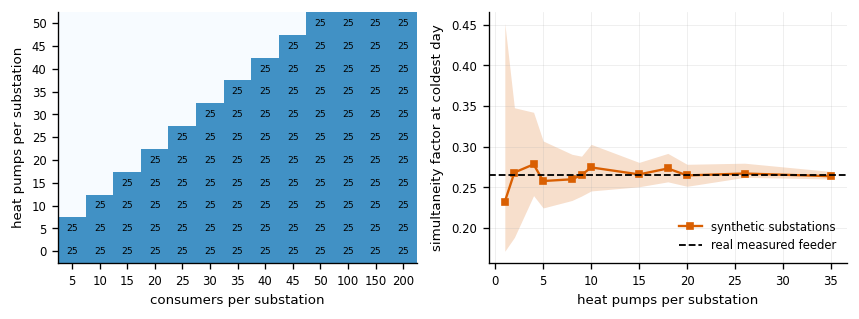

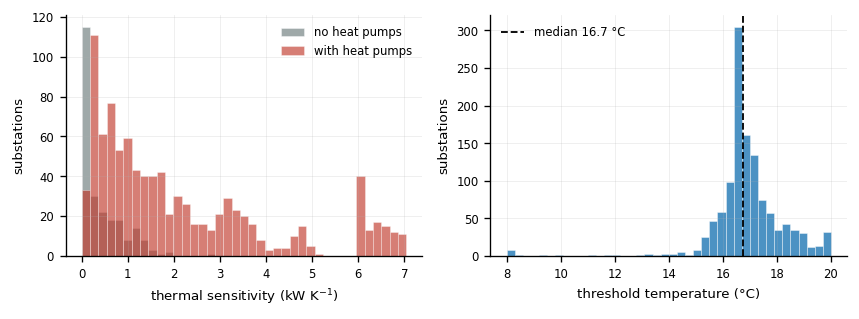

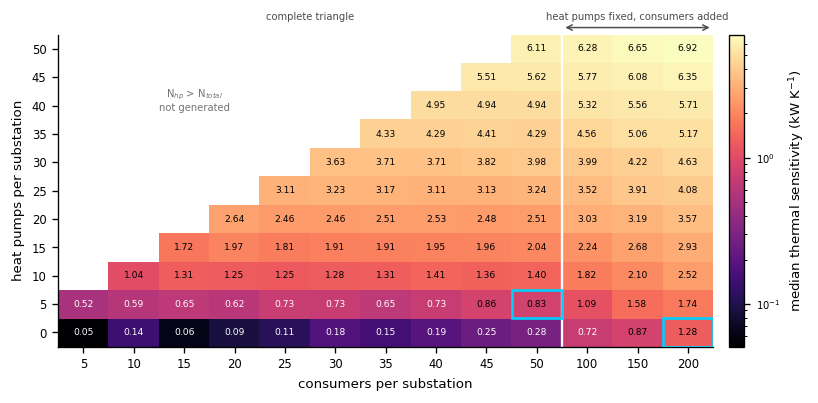

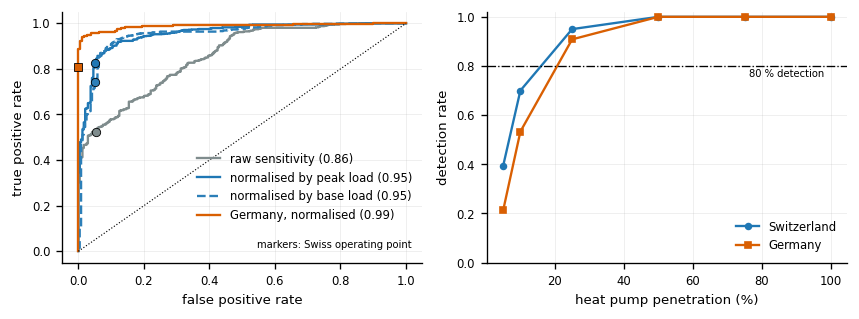

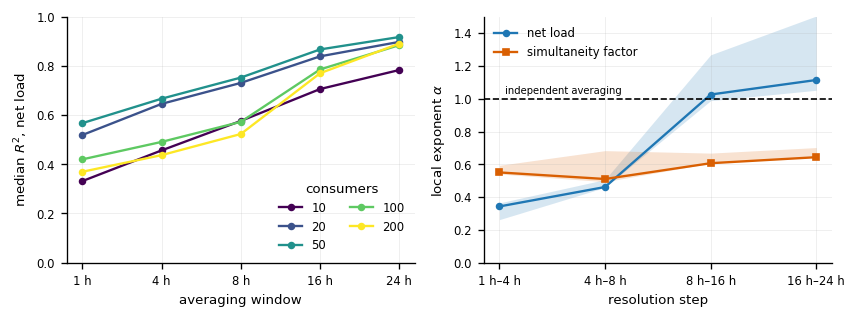

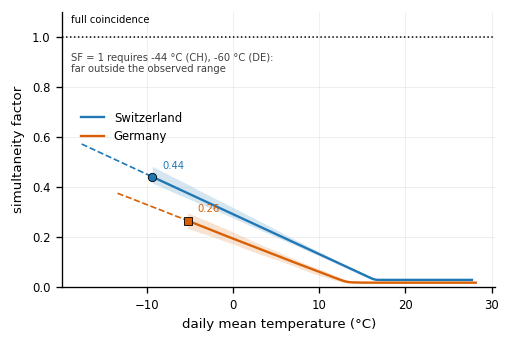

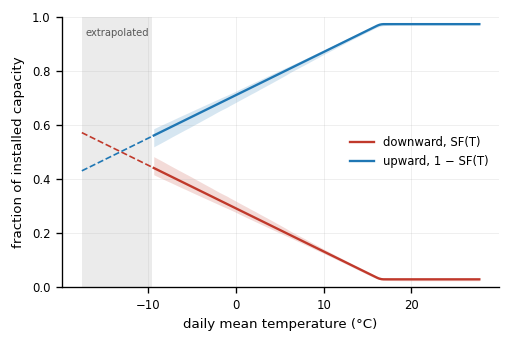

In [30]:
import hp_figures as hf
from hp_common import fit_hockey_stick

hf.use_style()

# quantities the figures need that are not already in memory
wsf24 = wpuq_sf[(wpuq_sf.resolution == '24 h') & (~wpuq_sf.failed)].copy()
wsf24['sf_cold'] = wsf24.base + wsf24.slope * np.maximum(
    0, wsf24.T_threshold - wsf24.T_min_obs)
env_de, rng_de = ha.flexibility_envelope(wpuq_fits[wpuq_fits.response == 'SF'],
                                         wpuq_design)
# Germany is scored at the Swiss threshold rather than its own, so the two
# curves share an operating point
det_de = ha.detection_at(wpuq_load, ha.detection_threshold(
    load_fits, 'slope_per_peak', '24 h')['threshold'])
det_ch = ha.detection_threshold(load_fits, 'slope_per_peak', '24 h')
s24 = sf_fits[(sf_fits.resolution == '24 h') & (~sf_fits.failed)]
tcrit_ch = s24.T_crit.replace([np.inf, -np.inf], np.nan).median()
tcrit_de = wsf24.T_crit.replace([np.inf, -np.inf], np.nan).median()

paths = [
    hf.fig1_design(meta_tri, wsf24, sf_real),
    hf.fig2_slopes(d24),
    hf.fig3_heatmap(d24_tri),
    hf.fig4_detection(load_fits, wpuq_load, det_ch, det_de),
    hf.fig5_scaling(fits),
    hf.fig6_sf(flex_ch_env if 'flex_ch_env' in dir() else flex, t_range,
               env_de, rng_de, tcrit_ch, tcrit_de),
    hf.fig7_flexibility(flex, t_range),
]
for p in paths:
    print('written', p + '.pdf', 'and', p + '.png')


## Summary

In [31]:
print('=' * 78)
print('COMBINED HEAPO + SWISS  —  '
      f'{len(meta)} substations, {pool_stats["households_used"]} households, '
      f'{pool_stats["hp_households_used"]} of {pool_stats["hp_households_available"]} HP households')
print('=' * 78)

print('\nNET LOAD, daily means')
print(f'  threshold temperature : {d24.T_threshold.median():.2f} °C '
      f'[IQR {d24.T_threshold.quantile(.25):.2f}, {d24.T_threshold.quantile(.75):.2f}]')
print(f'  slope, no heat pumps  : {no_hp.slope.median():.3f} kW/°C '
      f'[IQR {no_hp.slope.quantile(.25):.3f}, {no_hp.slope.quantile(.75):.3f}]')
print(f'  slope, with heat pumps: {with_hp.slope.median():.3f} kW/°C '
      f'[IQR {with_hp.slope.quantile(.25):.3f}, {with_hp.slope.quantile(.75):.3f}]')

print('\nDETECTION  (95 % specificity)')
for _s in ['slope', 'slope_per_peak']:
    _b = boot.set_index('statistic').loc[_s]
    print(f'  {_s:16s} threshold {_b.threshold:.4f} [{_b.thr_lo:.4f}, {_b.thr_hi:.4f}]'
          f'   AUC {_b.auc:.3f} [{_b.auc_lo:.3f}, {_b.auc_hi:.3f}]'
          f'   sens {_b.sensitivity:.2f} [{_b.sens_lo:.2f}, {_b.sens_hi:.2f}]')
_b = det_norm['by_hp_ratio']
_ok = _b[_b > 0.8]
print(f'  penetration needed for 80 % detection: '
      f'{(f"{_ok.index.min():.0%}" if len(_ok) else "not reached")}')
_best = res_contrast.loc[res_contrast.auc.idxmax()]
print(f'  best resolution for detection: {_best.resolution} (AUC {_best.auc:.3f}); '
      f'paired gain over 24 h {_best.d_auc_vs_ref:+.3f} '
      f'[{_best.d_auc_lo:+.3f}, {_best.d_auc_hi:+.3f}], '
      f'sensitivity {_best.d_sens_vs_ref:+.3f} '
      f'[{_best.d_sens_lo:+.3f}, {_best.d_sens_hi:+.3f}]')

print('\nSIMULTANEITY FACTOR, daily means')
print(f'  threshold temperature : {s24.T_threshold.median():.2f} °C '
      f'[IQR {s24.T_threshold.quantile(.25):.2f}, {s24.T_threshold.quantile(.75):.2f}]')
print(f'  slope                 : {s24.slope.median():.4f} 1/°C '
      f'[IQR {s24.slope.quantile(.25):.4f}, {s24.slope.quantile(.75):.4f}]')
print(f'  SF at coldest observed: {sf24.SF_at_coldest.median():.2f} '
      f'(no substation reaches 1; see section 3)')

print('\nFIT QUALITY')
_qm = ha.quality_model(fits, 'Load').set_index('term')
print(f'  per e-fold of Δt   : {_qm.loc["log_dt", "coef"]:+.3f} logit R²')
print(f'  per e-fold of N_hp : {_qm.loc["log_Nhp", "coef"]:+.3f}')
print(f'  per e-fold of N    : {_qm.loc["log_N", "coef"]:+.3f} (non-HP consumers dilute)')
print('\nSubstations are pseudo-replicates from a limited household pool; the')
print('effective sample size is well below the substation count.')


COMBINED HEAPO + SWISS  —  1200 substations, 1378 households, 71 of 81 HP households

NET LOAD, daily means
  threshold temperature : 16.75 °C [IQR 16.44, 17.42]
  slope, no heat pumps  : 0.194 kW/°C [IQR 0.114, 0.661]
  slope, with heat pumps: 1.449 kW/°C [IQR 0.629, 3.165]

DETECTION  (95 % specificity)
  slope            threshold 1.3481 [1.2109, 1.5527]   AUC 0.856 [0.830, 0.879]   sens 0.53 [0.48, 0.57]
  slope_per_peak   threshold 0.0191 [0.0173, 0.0226]   AUC 0.954 [0.941, 0.967]   sens 0.83 [0.63, 0.89]
  penetration needed for 80 % detection: 25%
  best resolution for detection: 8 h (AUC 0.962); paired gain over 24 h +0.008 [+0.004, +0.011], sensitivity +0.036 [-0.022, +0.120]

SIMULTANEITY FACTOR, daily means
  threshold temperature : 16.45 °C [IQR 16.09, 16.76]
  slope                 : 0.0160 1/°C [IQR 0.0150, 0.0176]
  SF at coldest observed: 0.42 (no substation reaches 1; see section 3)

FIT QUALITY
  per e-fold of Δt   : +0.662 logit R²
  per e-fold of N_hp : +0.959
  pe